# Day 31 Tutorial：第一个两层 GCN

## Goal

在 PyG `KarateClub` 教学图上完成一次两层 GCN 节点分类：读懂 shape、建立互斥掩码、只用训练节点计算 loss，并画出 train loss 与 validation accuracy 曲线。

**证据边界：** 这是教师提供的教学 Notebook，不是学习者实验成果，不包含分子或粘合剂数据；test 标签在本日保持封存。

## Setup

需要 `torch`、`torch_geometric`、`numpy`、`pandas` 和 `matplotlib`。先在终端确认环境：

```bash
python -c "import torch, torch_geometric; print(torch.__version__, torch_geometric.__version__)"
```

本 Notebook 不自动安装依赖，也不隐藏导入或训练错误。固定参数写在顶部，便于 Day 32–33 原样复用。

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch_geometric
from torch import nn
from torch.nn import functional as F
from torch_geometric.datasets import KarateClub
from torch_geometric.nn import GCNConv

MASK_SEED = 20260728
MODEL_SEED = 7
HIDDEN_CHANNELS = 16
EPOCHS = 120
DROPOUT = 0.5
LEARNING_RATE = 0.01
WEIGHT_DECAY = 5e-4

print("torch:", torch.__version__)
print("torch_geometric:", torch_geometric.__version__)

torch: 2.13.0
torch_geometric: 2.8.0.post1


## Steps

### 1. 加载一张图并建立固定掩码

KarateClub 自带少量训练节点。剩余节点只根据固定随机排列平分为 validation/test，划分过程不读取它们的标签。

In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def make_fixed_masks(graph, mask_seed=MASK_SEED):
    train_mask = graph.train_mask.clone()
    remaining_nodes = (~train_mask).nonzero(as_tuple=False).view(-1)

    generator = torch.Generator().manual_seed(mask_seed)
    order = torch.randperm(
        remaining_nodes.numel(),
        generator=generator,
    )
    remaining_nodes = remaining_nodes[order]

    valid_count = remaining_nodes.numel() // 2
    valid_nodes = remaining_nodes[:valid_count]
    test_nodes = remaining_nodes[valid_count:]

    valid_mask = torch.zeros(graph.num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(graph.num_nodes, dtype=torch.bool)
    valid_mask[valid_nodes] = True
    test_mask[test_nodes] = True
    return train_mask, valid_mask, test_mask


dataset = KarateClub()
data = dataset[0]
train_mask, valid_mask, test_mask = make_fixed_masks(data)

shape_table = pd.DataFrame(
    {
        "object": ["x", "edge_index", "y", "train_mask"],
        "shape": [
            str(tuple(data.x.shape)),
            str(tuple(data.edge_index.shape)),
            str(tuple(data.y.shape)),
            str(tuple(train_mask.shape)),
        ],
    }
)
display(shape_table)

print("nodes:", data.num_nodes)
print("features:", dataset.num_features)
print("classes:", dataset.num_classes)
print(
    "mask sizes:",
    {
        "train": int(train_mask.sum()),
        "validation": int(valid_mask.sum()),
        "test_sealed": int(test_mask.sum()),
    },
)

,object,shape
0,x,"(34, 34)"
1,edge_index,"(2, 156)"
2,y,"(34,)"
3,train_mask,"(34,)"


nodes: 34
features: 34
classes: 4
mask sizes: {'train': 4, 'validation': 15, 'test_sealed': 15}


### 2. 定义两层 GCN 并先检查前向 shape

行数始终是节点数 `N`；列数从输入特征 `F` 变为隐藏宽度 `16`，最后变为类别数 `C`。

In [3]:
class SmallGCN(nn.Module):
    def __init__(
        self,
        in_channels,
        hidden_channels,
        out_channels,
        dropout=0.5,
    ):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        hidden = self.conv1(x, edge_index)
        hidden = F.relu(hidden)
        hidden = F.dropout(
            hidden,
            p=self.dropout,
            training=self.training,
        )
        logits = self.conv2(hidden, edge_index)
        return logits


def count_trainable_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


set_seed(MODEL_SEED)
model = SmallGCN(
    in_channels=dataset.num_features,
    hidden_channels=HIDDEN_CHANNELS,
    out_channels=dataset.num_classes,
    dropout=DROPOUT,
)

model.eval()
with torch.no_grad():
    first_hidden = model.conv1(data.x, data.edge_index)
    initial_logits = model(data.x, data.edge_index)

print("x:", tuple(data.x.shape))
print("first hidden:", tuple(first_hidden.shape))
print("logits:", tuple(initial_logits.shape))
print("trainable parameters:", count_trainable_parameters(model))

x: (34, 34)
first hidden: (34, 16)
logits: (34, 4)
trainable parameters: 628


### 3. 训练 120 个 epoch

`model.train()` 启用 Dropout；loss 只索引 `train_mask`。随后用 `model.eval()` 与 `torch.no_grad()` 计算 validation，不调用 `backward()`。

In [4]:
def masked_accuracy(logits, labels, mask):
    predictions = logits.argmax(dim=1)
    correct = predictions[mask] == labels[mask]
    return correct.float().mean().item()


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()
    train_logits = model(data.x, data.edge_index)
    train_loss = F.cross_entropy(
        train_logits[train_mask],
        data.y[train_mask],
    )
    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        evaluation_logits = model(data.x, data.edge_index)
        valid_accuracy = masked_accuracy(
            evaluation_logits,
            data.y,
            valid_mask,
        )

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss.item(),
            "valid_accuracy": valid_accuracy,
        }
    )

history_table = pd.DataFrame(history)
display(history_table.iloc[[0, -1]])
print("final epoch validation accuracy:", history_table.iloc[-1]["valid_accuracy"])
print("固定训练 120 轮；没有按历史峰值保存或选择 checkpoint。")

,epoch,train_loss,valid_accuracy
0,1,1.401961,0.000000
119,120,0.049145,0.666667


final epoch validation accuracy: 0.6666666865348816
固定训练 120 轮；没有按历史峰值保存或选择 checkpoint。


### 4. 画出学习过程

曲线用于观察优化过程，不据此读取 test，也不把最好 validation epoch 包装成最终泛化性能。

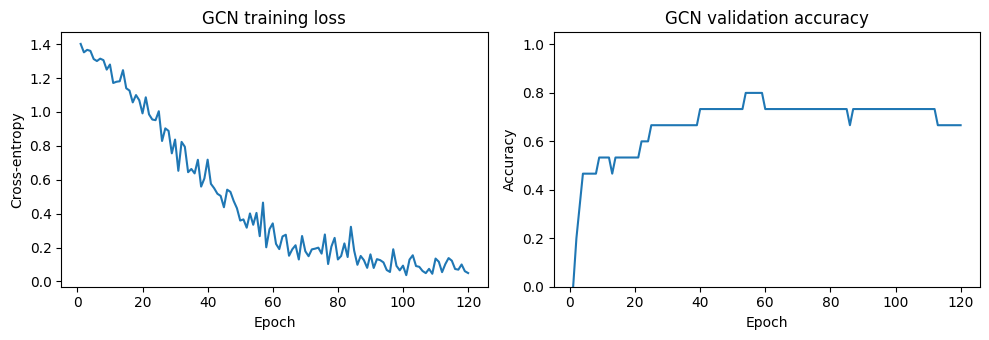

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(history_table["epoch"], history_table["train_loss"])
axes[0].set(
    title="GCN training loss",
    xlabel="Epoch",
    ylabel="Cross-entropy",
)

axes[1].plot(
    history_table["epoch"],
    history_table["valid_accuracy"],
    color="tab:blue",
)
axes[1].set(
    title="GCN validation accuracy",
    xlabel="Epoch",
    ylabel="Accuracy",
    ylim=(0, 1.05),
)

figure.tight_layout()
plt.show()

## Checks

下面只检查 shape、数值有限性和掩码边界。test 只以布尔掩码参与覆盖检查，不读取 test 标签或计算 test accuracy。

In [6]:
assert train_mask.dtype == torch.bool
assert valid_mask.dtype == torch.bool
assert test_mask.dtype == torch.bool
assert not torch.any(train_mask & valid_mask)
assert not torch.any(train_mask & test_mask)
assert not torch.any(valid_mask & test_mask)
assert torch.all(train_mask | valid_mask | test_mask)

assert first_hidden.shape == (data.num_nodes, HIDDEN_CHANNELS)
assert initial_logits.shape == (data.num_nodes, dataset.num_classes)
assert len(history_table) == EPOCHS
assert np.isfinite(history_table[["train_loss", "valid_accuracy"]]).all().all()
assert history_table["valid_accuracy"].between(0, 1).all()

print("Checks passed: shape、mask、有限数值均正确；test 标签未用于评价。")

Checks passed: shape、mask、有限数值均正确；test 标签未用于评价。


## Next Steps

1. 先独立完成 `03_exercises.md`，再查看参考答案。
2. 在 Day 32 保持当前数据、掩码、隐藏宽度、epoch 和种子集合不变。
3. 只把图算子替换为 GraphSAGE，并报告三种配对种子的 validation mean/std 与参数量。
4. 不把本教学图结果解释为分子或粘合剂结论。